In [17]:
import pandas as pd
import numpy as np
from sklearn.dummy import DummyRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.exceptions import IgnoredArgumentWarning

import seaborn as sns
sns.set_theme(palette="colorblind")

import warnings
warnings.simplefilter('ignore', category=IgnoredArgumentWarning) 


def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

rn = red_noise(obs=200, m=0, stdev=0.5, d=1, corr=0.7)
ts = pd.Series(rn, index=pd.date_range(start='2026-01-01', periods=len(rn), freq='D'))

<Axes: >

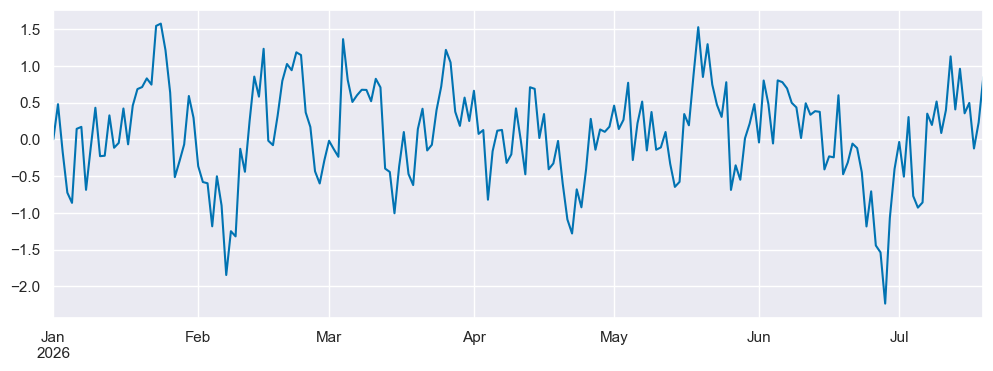

In [18]:
ts.plot(figsize=(12,4))

In [19]:
ts.mean()

np.float64(0.07731347051941496)

<Axes: >

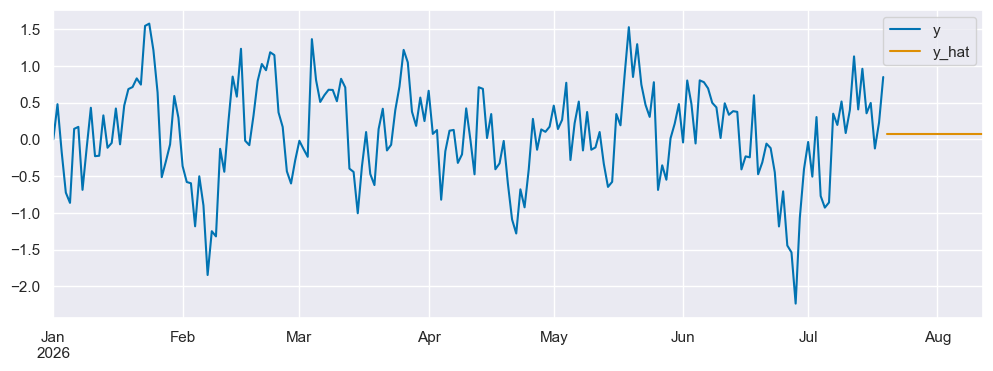

In [20]:
forecaster = ForecasterRecursive(
    estimator=DummyRegressor(strategy='mean'),
    lags=1
)
forecaster.fit(y=ts)
predictions = forecaster.predict(steps=24)

tdf = pd.DataFrame({"y": ts, "y_hat": predictions})
tdf.plot(figsize=(12,4))

# Backtesting

In [21]:
from skforecast.model_selection import TimeSeriesFold

cv = TimeSeriesFold(
         steps=1, # =forecast horizon
         initial_train_size=len(ts)-30, # size of the initial training set
         refit=False, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )
cv

============== 
TimeSeriesFold 
============== 
Initial train size    = 170,
Steps                 = 1,
Fold stride           = 1,
Overlapping folds     = False,
Window size           = None,
Differentiation       = None,
Refit                 = False,
Fixed train size      = False,
Gap                   = 0,
Skip folds            = None,
Allow incomplete fold = True,
Return all indexes    = False,
Verbose               = True

In [22]:
from skforecast.model_selection import backtesting_forecaster
from sklearn.metrics import root_mean_squared_error

forecaster = ForecasterRecursive(
    estimator=DummyRegressor(strategy='mean'),
    lags=1
)

results, predictions_backtest = backtesting_forecaster(
                                   forecaster=forecaster,
                                   y=ts,
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error', 
                                           'mean_absolute_percentage_error'],
                                   n_jobs='auto',
                                   verbose=True,
                                   show_progress=True
                               )

Information of folds
--------------------
Number of observations used for initial training: 170
Number of observations used for backtesting: 30
    Number of folds: 30
    Number skipped folds: 0 
    Number of steps per fold: 1
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   2026-01-01 00:00:00 -- 2026-06-19 00:00:00  (n=170)
    Validation: 2026-06-20 00:00:00 -- 2026-06-20 00:00:00  (n=1)
Fold: 1
    Training:   No training in this fold
    Validation: 2026-06-21 00:00:00 -- 2026-06-21 00:00:00  (n=1)
Fold: 2
    Training:   No training in this fold
    Validation: 2026-06-22 00:00:00 -- 2026-06-22 00:00:00  (n=1)
Fold: 3
    Training:   No training in this fold
    Validation: 2026-06-23 00:00:00 -- 2026-06-23 00:00:00  (n=1)
Fold: 4
    Training:   No training in this fold
    Validation: 2026-06-24 00:00:00 -- 2026-06-24 00:00:00  (n=1)
Fold: 5
    Training:   No training in this fold
    Validation: 2026-0

  0%|          | 0/30 [00:00<?, ?it/s]

In [23]:
results

,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
0,0.853015,0.654339,1.195386


<Axes: >

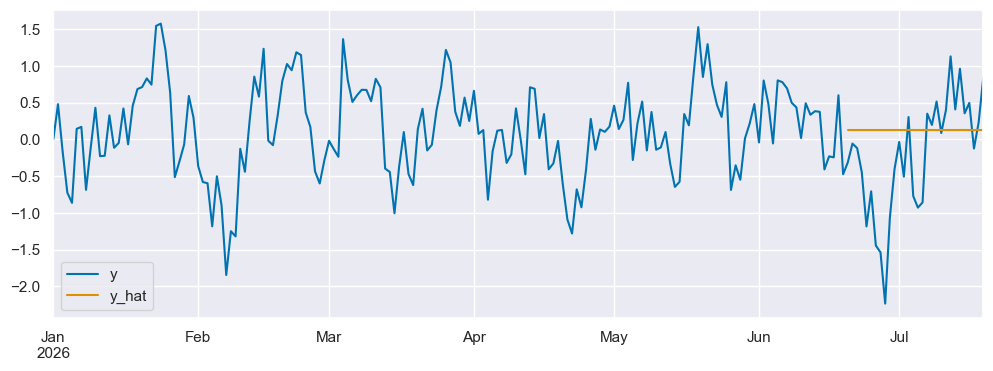

In [24]:
tdf = pd.DataFrame({"y": ts, "y_hat": predictions_backtest['pred']})
tdf.plot(figsize=(12,4))

In [25]:
predictions_backtest

,fold,pred
2026-06-20,0,0.129924
2026-06-21,1,0.129924
2026-06-22,2,0.129924
2026-06-23,3,0.129924
2026-06-24,4,0.129924
2026-06-25,5,0.129924
2026-06-26,6,0.129924
2026-06-27,7,0.129924
2026-06-28,8,0.129924
2026-06-29,9,0.129924
